In [4]:
# B-1. 가상 소비자 군체 구매확률 모델 + 몬테카를로 기준결과 시뮬레이터
# ============================================================
# 1. 학습 테이블 생성 (방문 x 고려상품 오퍼)
# 2. 시간순 Train / Validation / Test 분할
# 3. 1차 구현 (탄력성 규칙 + Logistic Regression)
# 4. 고도화 (CatBoost+Calibration, Monotonic LightGBM)
# 5. 모델 일괄 비교·평가 및 시뮬레이터 모델 선정
# 6. 가상 소비자 군체 (Monte Carlo 에이전트) 구성
# 7. 몬테카를로 기준결과 시뮬레이션 (기존 마감할인 정책 재현)
# 8. A-1 / B-2 인터페이스 산출물 저장
# ------------------------------------------------------------
# 1. 학습 테이블 생성
#    1-1. 라이브러리·경로 설정
#    1-2. CSV 데이터 로드 (B-1 사용 8개 파일)
#    1-3. 핵심 데이터 구조 점검
#    1-4. 일일 오퍼 테이블 생성 (할인 변형 단위)
#    1-5. 구매(positive) 라인 - 재고 로트 결합
#    1-6. 고객 Memory Stream 구축 (Generative Agents 차용)
#    1-7. 방문 표본·Negative 고려집합 표집
#    1-8. 통합 학습 테이블 + 피처 엔지니어링
# 2. 시간순 분할
#    2-1. Train(~9/30) / Valid(~11/15) / Test(~12/31)
#    2-2. 피처 목록 확정 (범주 12 + 수치 23)
# 3. 1차 구현
#    3-1. 상품군별 탄력성 규칙 모델 (lookup + smoothing)
#    3-2. Logistic Regression baseline
# 4. 고도화
#    4-1. CatBoost + Isotonic Calibration
#    4-2. Monotonic LightGBM (할인 단조 제약)
# 5. 모델 일괄 비교·평가
#    5-1. AUC / LogLoss / Brier / ECE 비교표
#    5-2. Calibration curve
#    5-3. 할인 반응곡선·단조성 진단 (+교란 실증)
#    5-4. 시뮬레이터 모델 선정·저장
# 6. 가상 소비자 군체
#    6-1. 페르소나·방문 표집 가중치·수량 분포
#    6-2. Memory 초기상태 스냅샷
#    6-3. 오퍼 문맥·구매확률 predict 함수
# 7. 몬테카를로 기준결과 시뮬레이션
#    7-1. 시뮬레이션 프로토콜 (run_sim)
#    7-2. 강도 보정 계수 산출 (검증기간, IPF)
#    7-3. 기준결과 N=20회 실행 (테스트기간)
#    7-4. 현실 정합성 검증 (+시각화)
# 8. A-1 / B-2 인터페이스 산출물
#    8-1. 기준결과 테이블 (store x date x slot x product)
#    8-2. 기존 마감할인 정책 테이블
#    8-3. 가상 소비자 군체(agent pool) 저장
#    8-4. predict 입력 스키마·프로토콜 상수 (JSON)

# ------------------------------------------------------------
# [v3 고도화 반영 사항 - 팀 피드백 기반]
#  1) 오퍼 필터 강화: EXPIRED·기한경과·가용0 로트를 판매 노출에서 제외
#  2) 고려집합 비복원 추출: 같은 오퍼가 한 고객에게 중복으로 뽑히지 않음
#  3) 재고량 비례 노출: 재고 많은 오퍼가 더 자주 눈에 띄도록 가중 표집
#  4) 반응곡선(모델 선정 근거)을 검증구간에서 산출 (시험구간 누수 방지)
#  5) 용어 정정: 본 확률은 "후보 오퍼 내 선택확률"이며 절대 구매확률이 아님
#     탄력성 라벨: empirical -> 중간 탄력성 가정 / upper -> 상단 탄력성 가정
# ------------------------------------------------------------

In [5]:
# ============================================================
# 1-1. 라이브러리·경로 설정
# ============================================================
# Colab 실행 시: 데이터 CSV를 /content 에 업로드한 뒤 전체 실행 (런타임 약 20~30분)
# lightgbm / catboost 미설치 환경이면 아래 주석 해제
!pip -q install lightgbm catboost

import os, json, time, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED)

# 데이터 경로 자동 탐지 (Colab: /content 우선)
CAND_DIRS = [Path("/content"), Path("/content/data"), Path("/mnt/user-data/uploads"), Path(".")]
DATA_DIR = next(d for d in CAND_DIRS if (d / "customer.csv").exists())
OUTPUT_DIR = (Path("/content") if Path("/content").exists() else Path(".")) / "b1_outputs"
MODEL_DIR = OUTPUT_DIR / "models"; REPORT_DIR = OUTPUT_DIR / "reports"; IFACE_DIR = OUTPUT_DIR / "interface"
for d in [OUTPUT_DIR, MODEL_DIR, REPORT_DIR, IFACE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def save_df(df, name):
    """중간 산출물 저장: parquet 우선, 불가하면 pickle."""
    try:
        df.to_parquet(OUTPUT_DIR / f"{name}.parquet")
    except Exception:
        df.to_pickle(OUTPUT_DIR / f"{name}.pkl")

print("DATA_DIR:", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.5 MB/s eta 0:00:00
DATA_DIR: /content
OUTPUT_DIR: /content/b1_outputs


In [6]:
# ============================================================
# 1-2. CSV 데이터 로드 (B-1 사용 8개 파일)
# ============================================================
# 사용: customer / product / store / calendar / store_visitor_profile / visitor / receipt / inventory
# 제외: transaction(receipt와 중복 정보), store_calendar(영업시간은 A-1 담당 범위)
customer_df  = pd.read_csv(DATA_DIR / "customer.csv")
product_df   = pd.read_csv(DATA_DIR / "product.csv")
store_df     = pd.read_csv(DATA_DIR / "store.csv")
calendar_df  = pd.read_csv(DATA_DIR / "calendar.csv", parse_dates=["date"])
svp_df       = pd.read_csv(DATA_DIR / "store_visitor_profile.csv")
visitor_df   = pd.read_csv(DATA_DIR / "visitor.csv", parse_dates=["visit_date"])
receipt_df   = pd.read_csv(DATA_DIR / "receipt.csv", parse_dates=["sale_date"])
inventory_df = pd.read_csv(DATA_DIR / "inventory.csv", parse_dates=["current_date"])

# ==== [데이터 v2 대응] 스키마 검증 (데이터팀 합의: 2026-07 갱신) ====
# 1) sold_out_flag 컬럼 존재 (신규): SOLD_OUT 상태 로트 식별
assert "sold_out_flag" in inventory_df.columns, "inventory.csv에 sold_out_flag 없음 - 구버전 데이터"
# 2) sold_out_flag와 inventory_status 일치 확인
_m = (inventory_df["inventory_status"] == "SOLD_OUT") == (inventory_df["sold_out_flag"] == 1)
assert _m.all(), f"sold_out_flag 불일치 {(~_m).sum()}행"
# 3) EXPIRED 행 유지 확인 (폐기 검증 정답으로 사용하므로 필수)
assert (inventory_df["inventory_status"] == "EXPIRED").any(), "EXPIRED 행 없음 - 폐기 검증 불가"
print("데이터 v2 스키마 검증 통과: sold_out_flag 일치, EXPIRED 유지")

# 키 타입 통일
for df in [store_df, visitor_df, receipt_df, inventory_df]:
    df["store_id"] = df["store_id"].astype(str)
for df in [product_df, receipt_df, inventory_df]:
    df["product_id"] = df["product_id"].astype(str)

print({k: v.shape for k, v in dict(customer=customer_df, product=product_df,
       store=store_df, calendar=calendar_df, store_visitor_profile=svp_df,
       visitor=visitor_df, receipt=receipt_df, inventory=inventory_df).items()})


{'customer': (10000, 9), 'product': (38, 17), 'store': (3, 11), 'calendar': (365, 15), 'store_visitor_profile': (45, 8), 'visitor': (629170, 8), 'receipt': (118791, 18), 'inventory': (75537, 23)}


In [7]:
# ============================================================
# 1-3. 핵심 데이터 구조 점검
# ============================================================
# (1) receipt의 inventory_id 가 inventory에 존재하는가 -> 로트 상태 직접 결합 가능 여부
in_inv = receipt_df["inventory_id"].isin(set(inventory_df["inventory_id"])).mean()
print("receipt.inventory_id 가 inventory에 존재하는 비율:", round(in_inv, 4))

# (2) 할인율 단위 확인: receipt / inventory 는 0~40 '정수 %', product.max_discount_rate 는 0~0.4 '비율'
print("receipt.discount_rate 분포(%):")
print(receipt_df["discount_rate"].value_counts().sort_index().to_string())
print("product.max_discount_rate 예시(비율):", sorted(product_df["max_discount_rate"].unique()))

# (3) 방문 시간대(slot) 체계 - A-1의 hour 격자와 다르므로 인터페이스 문서 참조
print("time_slot:", sorted(visitor_df["time_slot"].unique()))
print("기간:", visitor_df["visit_date"].min().date(), "~", visitor_df["visit_date"].max().date())


receipt.inventory_id 가 inventory에 존재하는 비율: 1.0
receipt.discount_rate 분포(%):
discount_rate
0     83179
10       50
11     3227
12     6404
13     2060
14      752
15     1030
16    12258
29       75
30     1517
31        1
32     2776
33      724
34       10
35     4280
36      447
37        1
product.max_discount_rate 예시(비율): [np.float64(0.4)]
time_slot: ['afternoon', 'closing', 'evening', 'lunch', 'morning']
기간: 2025-01-01 ~ 2025-12-31


In [8]:
# ============================================================
# 1-4. 일일 오퍼 테이블 생성 (기존 마감할인 정책이 기록된 상태)
# ============================================================
# inventory 로트를 (store, product, date, discount_rate) 단위 '오퍼 변형'으로 집계.
# 같은 상품이라도 그날 매대에는 '정가 신선 로트'와 '임박 할인 로트'가 동시에 존재할 수 있고,
# 소비자는 그중 하나를 고르는 상황이므로 할인 변형을 별도 행으로 유지한다.
inv = inventory_df.copy()
# [데이터 v2] 품절 로트는 매대 노출(오퍼)에서 명시적으로 제외 (데이터팀 규칙 준수)
inv = inv[inv["sold_out_flag"] == 0].copy()
# [피드백 반영] 만료/판매불가 로트는 판매 오퍼에서 제외 (EXPIRED 행은 폐기 정답으로만 사용)
inv = inv[(inv["inventory_status"] != "EXPIRED") & (inv["days_to_expiry"] >= 0) & (inv["available_qty"] > 0)].copy()
inv["discount_rate"] = pd.to_numeric(inv["discount_rate"], errors="coerce").fillna(0).astype(int)
offer_df = (inv.groupby(["store_id", "product_id", "current_date", "discount_rate"], as_index=False)
              .agg(days_to_expiry=("days_to_expiry", "min"),
                   freshness_score=("freshness_score", "mean"),
                   available_qty=("available_qty", "sum"),
                   unit_price=("unit_price", "first"),
                   discount_price=("discount_price", "min")))
offer_df = offer_df.rename(columns={"current_date": "date"})
offer_df["discount_ratio"] = offer_df["discount_rate"] / 100.0
offer_df = offer_df.merge(product_df[["product_id", "category", "base_price",
                                      "shelf_life_days", "freshness_decay_type"]],
                          on="product_id", how="left")
offer_df["offer_id"] = np.arange(len(offer_df))
print("offer_df:", offer_df.shape)
print(offer_df.head(3).to_string())


offer_df: (53249, 15)
  store_id product_id       date  discount_rate  days_to_expiry  freshness_score  available_qty  unit_price  discount_price  discount_ratio category  base_price  shelf_life_days freshness_decay_type  offer_id
0      S01       P001 2025-01-01              0               6         0.681850             28        6500            6500            0.00  produce        6500               10               medium         0
1      S01       P001 2025-01-01             36               0         0.090900              5        6500            4160            0.36  produce        6500               10               medium         1
2      S01       P001 2025-01-02              0              -1         0.393967             16        6500            6500            0.00  produce        6500               10               medium         2


In [9]:
# ============================================================
# 1-5. 구매(positive) 라인 - 재고 로트 결합
# ============================================================
# receipt 라인은 inventory_id 를 담고 있어, 구매 당시 로트의 잔여 유통기한·신선도를 결측 없이 결합 가능.
vis = visitor_df.merge(customer_df, on="customer_id", how="left")

rec = receipt_df.merge(
    inventory_df[["inventory_id", "days_to_expiry", "freshness_score", "available_qty"]],
    on="inventory_id", how="left")
rec["discount_rate"] = pd.to_numeric(rec["discount_rate"], errors="coerce").fillna(0).astype(int)
rec = rec.merge(product_df[["product_id", "category", "base_price",
                            "shelf_life_days", "freshness_decay_type"]],
                on="product_id", how="left")
print("positive rows:", len(rec), " / 로트 결합 결측률:", rec["days_to_expiry"].isna().mean())


positive rows: 118791  / 로트 결합 결측률: 0.0


In [10]:
# ============================================================
# 1-6. 고객 Memory Stream 구축 (Generative Agents, Park et al. 2023 차용)
# ============================================================
# 논문의 memory stream = "경험을 기록하고 recency(최신성) 가중으로 회상"
# 구현: 고객의 과거 구매 이벤트를 기록하고, 하루 지날 때마다 점수를 0.97배 감쇠.
#   s_k = s_{k-1} * DECAY^(경과일) + 1   (구매 시 +1)
# 3종 상태를 유지한다.
#  (a) 고객 x 카테고리 기억 점수 / 마지막 구매 경과일
#  (b) 고객 x 상품 기억 점수 / 마지막 구매 경과일
#  (c) 고객 '할인 구매 성향' EWMA (구매 시 할인율의 지수이동평균, alpha=0.2)
MEM_DECAY = 0.97

events = rec[["customer_id", "sale_date", "category", "product_id",
              "discount_rate", "quantity"]].copy()

def build_decay_state(ev, keys):
    """키 그룹별 이벤트 시점의 감쇠 누적 점수를 O(n)으로 계산."""
    ev = ev.sort_values(keys + ["sale_date"]).reset_index(drop=True)
    grp = ev.groupby(keys, sort=False).ngroup().to_numpy()
    dates = ev["sale_date"].values.astype("datetime64[D]").astype(int)
    score = np.zeros(len(ev))
    s_prev = 0.0; d_prev = 0; g_prev = -1
    for i in range(len(ev)):
        if grp[i] != g_prev:
            s = 1.0
        else:
            s = s_prev * (MEM_DECAY ** (dates[i] - d_prev)) + 1.0
        score[i] = s
        s_prev, d_prev, g_prev = s, dates[i], grp[i]
    ev["mem_score_at_event"] = score
    return ev

t0 = time.time()
ev_cat  = build_decay_state(events, ["customer_id", "category"])
ev_prod = build_decay_state(events, ["customer_id", "product_id"])

# (c) 할인 구매 성향 EWMA
ev_cust = events.sort_values(["customer_id", "sale_date"]).reset_index(drop=True)
gc = ev_cust.groupby("customer_id", sort=False).ngroup().to_numpy()
dr = ev_cust["discount_rate"].to_numpy(float)
ew = np.zeros(len(ev_cust)); alpha = 0.2
prev = 0.0; gp = -1
for i in range(len(ev_cust)):
    if gc[i] != gp:
        prev = dr[i]
    else:
        prev = (1 - alpha) * prev + alpha * dr[i]
    ew[i] = prev; gp = gc[i]
ev_cust["deal_ewma_at_event"] = ew
print("memory stream built:", round(time.time() - t0, 1), "s")

def asof_memory(query_df, date_col, ev, keys, prefix):
    """query 시점 '직전'(같은 날 제외 -> 누수 방지)의 memory 상태를 asof join으로 조회."""
    q = query_df[keys + [date_col]].copy()
    q["_row"] = np.arange(len(q))
    q = q.sort_values(date_col)
    e = ev.sort_values("sale_date")
    cols = [c for c in ["mem_score_at_event", "deal_ewma_at_event"] if c in e.columns]
    m = pd.merge_asof(q, e[keys + ["sale_date"] + cols],
                      left_on=date_col, right_on="sale_date",
                      by=keys, allow_exact_matches=False)
    out = pd.DataFrame(index=np.arange(len(q)))
    gap = (m[date_col] - m["sale_date"]).dt.days
    if "mem_score_at_event" in cols:
        out[f"{prefix}_score"] = (m["mem_score_at_event"] * (MEM_DECAY ** gap)).fillna(0.0).to_numpy()
        out[f"{prefix}_days_since"] = gap.fillna(999).clip(0, 999).to_numpy()
    if "deal_ewma_at_event" in cols:
        out[f"{prefix}_deal_ewma"] = m["deal_ewma_at_event"].fillna(-1).to_numpy()
    out["_row"] = m["_row"].to_numpy()
    return out.sort_values("_row").drop(columns="_row").reset_index(drop=True)


memory stream built: 1.0 s


In [11]:
# ============================================================
# 1-7. 방문 표본·Negative 고려집합 표집
# ============================================================
# 라벨 구조: 방문 x 오퍼 단위로 y=1(그 방문에서 실제 구매) / y=0(그날 매대에 있었지만 미구매).
# negative 는 방문당 K_NEG=4개를 '고려집합' 프로토콜로 표집:
#   각 슬롯은 확률 PREF_BOOST=0.5 로 '선호 카테고리 내 균등', 나머지는 '전체 오퍼 균등'.
# 이 프로토콜 상수는 7장 시뮬레이터와 B-2 최적화가 반드시 동일하게 사용해야 한다.
VISIT_FRAC = 0.40   # 방문 이벤트 균등 40% 표본 (메모리·시간 절약, 시간 편향 없음)
K_NEG = 4
PREF_BOOST = 0.5

vis_s = vis.sample(frac=VISIT_FRAC, random_state=SEED).reset_index(drop=True)
pos_in_sample = rec[rec["visitor_id"].isin(set(vis_s["visitor_id"]))].copy()
print("sampled visits:", len(vis_s), "/ positives in sample:", len(pos_in_sample))

rng = np.random.default_rng(SEED)
grp_offers = {k: g for k, g in offer_df.groupby(["store_id", "date"])}
neg_rows = []
t0 = time.time()
for (sid, d), gv in vis_s.groupby(["store_id", "visit_date"], sort=False):
    go = grp_offers.get((sid, d))
    if go is None or len(go) == 0:
        continue
    n_v = len(gv); n_o = len(go)
    cats = go["category"].to_numpy()
    pref = gv["preferred_category"].to_numpy()
    # [피드백 반영] 노출확률 = 가용재고량 비례, 고객별 후보는 비복원 추출(중복 금지)
    _av = go["available_qty"].to_numpy(float).clip(0.0) + 1e-9
    p_exp = _av / _av.sum()
    kk = min(K_NEG, n_o)
    idx_all = np.stack([rng.choice(n_o, size=kk, replace=False, p=p_exp) for _ in range(n_v)])
    use_pref = rng.random((n_v, kk)) < PREF_BOOST
    cat_idx = {c: np.where(cats == c)[0] for c in np.unique(cats)}
    for j, c in enumerate(pref):
        ci = cat_idx.get(c)
        if ci is None or len(ci) == 0:
            use_pref[j, :] = False
            continue
        take = use_pref[j]
        if take.any():
            # 선호 카테고리 내에서도 재고 가중·비복원, 기존 선택과 중복 회피
            pc = p_exp[ci] / p_exp[ci].sum()
            picks = rng.choice(ci, size=min(take.sum(), len(ci)), replace=False, p=pc)
            slots = np.where(take)[0][:len(picks)]
            for s_, pk in zip(slots, picks):
                if pk not in idx_all[j]:
                    idx_all[j, s_] = pk
    chosen = go["offer_id"].to_numpy()[idx_all]
    neg_rows.append(pd.DataFrame({
        "visitor_id": np.repeat(gv["visitor_id"].to_numpy(), K_NEG),
        "offer_id": chosen.ravel()}))
neg_df = pd.concat(neg_rows, ignore_index=True)
print("negatives sampled:", len(neg_df), "(", round(time.time() - t0, 1), "s )")


sampled visits: 251668 / positives in sample: 47293
negatives sampled: 1006672 ( 16.3 s )


In [12]:
# ============================================================
# 1-8. 통합 학습 테이블 + 피처 엔지니어링
# ============================================================
neg_full = neg_df.merge(offer_df, on="offer_id", how="left")
neg_full = neg_full.merge(
    vis_s[["visitor_id", "customer_id", "store_id", "visit_date", "time_slot", "day_type"]],
    on="visitor_id", how="left", suffixes=("_off", ""))
neg_full = neg_full.rename(columns={"visit_date": "date_"})
neg_full["y"] = 0

pos_full = pos_in_sample.rename(columns={"sale_date": "date_"}).copy()
pos_full["discount_ratio"] = pos_full["discount_rate"] / 100.0
pos_full["y"] = 1

use_cols = ["visitor_id", "customer_id", "store_id", "date_", "time_slot",
            "product_id", "category", "base_price", "shelf_life_days",
            "freshness_decay_type", "discount_rate", "discount_ratio",
            "days_to_expiry", "freshness_score", "y"]
train_tbl = pd.concat([pos_full[use_cols], neg_full[use_cols]], ignore_index=True)

# 같은 방문에서 실제 구매한 (상품, 할인율)이 negative로도 뽑힌 경우 -> positive만 유지
train_tbl = (train_tbl.sort_values("y", ascending=False)
                      .drop_duplicates(["visitor_id", "product_id", "discount_rate"], keep="first")
                      .reset_index(drop=True))
print("train_tbl:", train_tbl.shape, "/ y-rate:", round(train_tbl["y"].mean(), 4))

# 고객·달력·점포 피처 결합
train_tbl = train_tbl.merge(customer_df, on="customer_id", how="left")
cal_cols = ["date", "day_of_week", "is_weekend", "is_holiday", "season", "month", "day_type"]
train_tbl = train_tbl.merge(
    calendar_df[cal_cols].rename(columns={"date": "date_", "day_type": "day_type_cal"}),
    on="date_", how="left")
train_tbl = train_tbl.merge(store_df[["store_id", "area_type", "floating_idx"]], on="store_id", how="left")

# memory stream 피처 (당일 이전 상태만 -> 누수 방지)
mcat  = asof_memory(train_tbl.rename(columns={"date_": "qdate"}), "qdate", ev_cat,  ["customer_id", "category"],   "mem_cat")
mprod = asof_memory(train_tbl.rename(columns={"date_": "qdate"}), "qdate", ev_prod, ["customer_id", "product_id"], "mem_prod")
mdeal = asof_memory(train_tbl.rename(columns={"date_": "qdate"}), "qdate", ev_cust, ["customer_id"],               "mem_cust")
train_tbl = pd.concat([train_tbl, mcat, mprod, mdeal[["mem_cust_deal_ewma"]]], axis=1)

# 파생 피처
train_tbl["is_pref_category"] = (train_tbl["category"] == train_tbl["preferred_category"]).astype(int)
train_tbl["expiry_ratio"] = (train_tbl["days_to_expiry"] / train_tbl["shelf_life_days"]).clip(0, 1)
train_tbl["log_base_price"] = np.log1p(train_tbl["base_price"])
train_tbl["ps_x_disc"] = train_tbl["price_sensitivity"] * train_tbl["discount_ratio"]
train_tbl["fs_x_fresh"] = train_tbl["freshness_sensitivity"] * train_tbl["freshness_score"]

# 오퍼 문맥 피처: 같은 (점포,상품,날짜)의 변형 수 / '정가 신선 대안' 존재 여부
ctx = (offer_df.assign(is_fresh_alt=((offer_df["discount_rate"] == 0) & (offer_df["days_to_expiry"] > 2)).astype(int))
       .groupby(["store_id", "product_id", "date"], as_index=False)
       .agg(variant_count=("offer_id", "count"), fresh_alt_available=("is_fresh_alt", "max")))
train_tbl = train_tbl.merge(ctx.rename(columns={"date": "date_"}),
                            on=["store_id", "product_id", "date_"], how="left")
train_tbl["variant_count"] = train_tbl["variant_count"].fillna(1)
train_tbl["fresh_alt_available"] = train_tbl["fresh_alt_available"].fillna(0)
train_tbl["near_expiry"] = (train_tbl["days_to_expiry"] <= 1).astype(int)
train_tbl["disc_x_near"] = train_tbl["discount_ratio"] * train_tbl["near_expiry"]
print("features joined:", train_tbl.shape)

save_df(train_tbl, "b1_train_table"); save_df(offer_df, "offer_df")
save_df(ev_cat, "ev_cat"); save_df(ev_prod, "ev_prod"); save_df(ev_cust, "ev_cust")
save_df(rec, "rec")
save_df(vis[["visitor_id", "customer_id", "store_id", "visit_date", "time_slot", "day_type"]], "vis")
print("intermediate saved ->", OUTPUT_DIR)


train_tbl: (984572, 15) / y-rate: 0.048
features joined: (984572, 45)
intermediate saved -> /content/b1_outputs


In [13]:
# ============================================================
# 2. 시간순 Train / Validation / Test 분할 + 피처 목록 확정
# ============================================================
# 미래 데이터 누수를 막기 위해 무작위 분할이 아닌 '시간순' 분할을 사용한다.
TRAIN_END = pd.Timestamp("2025-09-30")
VALID_END = pd.Timestamp("2025-11-15")
d = train_tbl["date_"]
tr = train_tbl[d <= TRAIN_END].reset_index(drop=True)
va = train_tbl[(d > TRAIN_END) & (d <= VALID_END)].reset_index(drop=True)
te = train_tbl[d > VALID_END].reset_index(drop=True)
print({s: (len(x), round(x["y"].mean(), 4)) for s, x in dict(train=tr, valid=va, test=te).items()})

# 2-2. 피처 목록 (범주 12 + 수치 23)
# 주의: effective_price 는 discount_ratio 와 정보가 중복되고 단조 제약을 우회하는
#       누출 채널이 되므로 제외했다. (가격 수준은 log_base_price 가 담당)
CAT_FEATURES = ["category", "time_slot", "day_type_cal", "season", "day_of_week",
                "area_type", "age_group", "household_type", "income_level",
                "residence_type", "visit_frequency", "freshness_decay_type"]
NUM_FEATURES = ["discount_ratio", "days_to_expiry", "expiry_ratio", "freshness_score",
                "log_base_price", "price_sensitivity",
                "freshness_sensitivity", "is_pref_category", "is_weekend", "is_holiday",
                "month", "floating_idx", "mem_cat_score", "mem_cat_days_since",
                "mem_prod_score", "mem_prod_days_since", "mem_cust_deal_ewma",
                "ps_x_disc", "fs_x_fresh", "variant_count", "fresh_alt_available",
                "near_expiry", "disc_x_near"]
ALL_FEATURES = CAT_FEATURES + NUM_FEATURES

for df in (tr, va, te):
    for c in CAT_FEATURES:
        df[c] = df[c].astype(str).fillna("NA")
    for c in NUM_FEATURES:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss

def ece_score(y, p, bins=10):
    """Expected Calibration Error: 예측확률과 실제 빈도의 구간별 가중 차이."""
    edges = np.linspace(0, 1, bins + 1)
    idx = np.clip(np.digitize(p, edges) - 1, 0, bins - 1)
    e = 0.0
    for b in range(bins):
        m = idx == b
        if m.sum() == 0:
            continue
        e += m.mean() * abs(y[m].mean() - p[m].mean())
    return e

def evaluate(name, y, p):
    return dict(model=name, AUC=roc_auc_score(y, p), LogLoss=log_loss(y, p),
                Brier=brier_score_loss(y, p), ECE=ece_score(np.asarray(y), np.asarray(p)))
print("피처:", len(CAT_FEATURES), "+", len(NUM_FEATURES), "=", len(ALL_FEATURES))


{'train': (735728, np.float64(0.0483)), 'valid': (125026, np.float64(0.0472)), 'test': (123818, np.float64(0.0472))}
피처: 12 + 23 = 35


In [14]:
# ============================================================
# 3-1. 상품군별 탄력성 규칙 모델 (1차 구현 (1))
# ============================================================
# 해석 가능한 lookup 규칙: category x 할인 5구간 x 가격민감도 3분위별 구매율 표.
# 관측이 적은 칸은 카테고리 평균으로 Laplace smoothing(s=50).
DISC_BINS = [-0.01, 0.0, 0.10, 0.20, 0.30, 0.41]
DISC_LABELS = ["d00", "d10", "d20", "d30", "d40"]

class ElasticityRuleModel:
    """category x 할인구간 x 가격민감도 3분위 lookup + Laplace smoothing."""
    def __init__(self, smoothing=50):
        self.smoothing = smoothing
    def _keys(self, df):
        db = pd.cut(df["discount_ratio"], DISC_BINS, labels=DISC_LABELS).astype(str)
        ps = pd.cut(df["price_sensitivity"], self.ps_edges, labels=["psL", "psM", "psH"],
                    include_lowest=True).astype(str)
        return df["category"].astype(str), db, ps
    def fit(self, df, y):
        self.ps_edges = np.quantile(df["price_sensitivity"], [0, 1/3, 2/3, 1.0])
        self.ps_edges[0] -= 1e-6
        cat, db, ps = self._keys(df)
        base = pd.DataFrame({"cat": cat, "db": db, "ps": ps, "y": y})
        self.global_rate = y.mean()
        self.cat_rate = base.groupby("cat")["y"].mean().to_dict()
        g = base.groupby(["cat", "db", "ps"])["y"].agg(["sum", "count"])
        s = self.smoothing
        self.table = {}
        for (c, b, p_), r in g.iterrows():
            prior = self.cat_rate.get(c, self.global_rate)
            self.table[(c, b, p_)] = (r["sum"] + s * prior) / (r["count"] + s)
        return self
    def predict_proba_pos(self, df):
        cat, db, ps = self._keys(df)
        out = np.empty(len(df))
        for i, key in enumerate(zip(cat, db, ps)):
            out[i] = self.table.get(key, self.cat_rate.get(key[0], self.global_rate))
        return out

t0 = time.time()
rule_model = ElasticityRuleModel().fit(tr, tr["y"])
p_rule_va = rule_model.predict_proba_pos(va)
p_rule_te = rule_model.predict_proba_pos(te)
print("rule fitted:", round(time.time() - t0, 1), "s")


rule fitted: 0.6 s


In [15]:
# ============================================================
# 3-2. Logistic Regression baseline (1차 구현 (2))
# ============================================================
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

lr_pipe = Pipeline([
    ("prep", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_FEATURES),
        ("num", StandardScaler(), NUM_FEATURES)])),
    ("clf", LogisticRegression(max_iter=2000, C=1.0, solver="lbfgs"))])
t0 = time.time()
lr_pipe.fit(tr[ALL_FEATURES], tr["y"])
p_lr_va = lr_pipe.predict_proba(va[ALL_FEATURES])[:, 1]
p_lr_te = lr_pipe.predict_proba(te[ALL_FEATURES])[:, 1]
print("LR fitted:", round(time.time() - t0, 1), "s")


LR fitted: 8.9 s


In [16]:
# ============================================================
# 4-1. CatBoost + Isotonic Calibration (고도화 (1))
# ============================================================
# Colab 등에 catboost / lightgbm 이 없으면 sklearn HistGradientBoosting 으로 자동 대체.
# (Claude 검증 실행 환경은 네트워크 차단으로 fallback 사용 - 결과 해석 동일)
try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
except ImportError:
    HAS_CATBOOST = False
try:
    import lightgbm as lgb
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
print("catboost:", HAS_CATBOOST, "/ lightgbm:", HAS_LGBM)

from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.isotonic import IsotonicRegression

enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
enc.fit(tr[CAT_FEATURES])
def enc_X(df):
    return np.hstack([enc.transform(df[CAT_FEATURES]), df[NUM_FEATURES].to_numpy(float)])
FEATL = CAT_FEATURES + NUM_FEATURES
Xtr, Xva, Xte = enc_X(tr), enc_X(va), enc_X(te)
ytr, yva, yte = tr["y"].to_numpy(), va["y"].to_numpy(), te["y"].to_numpy()

t0 = time.time()
if HAS_CATBOOST:
    cb = CatBoostClassifier(iterations=600, depth=8, learning_rate=0.08,
                            loss_function="Logloss", random_seed=SEED, verbose=0,
                            cat_features=list(range(len(CAT_FEATURES))))
    Xtr_cb = pd.concat([tr[CAT_FEATURES], tr[NUM_FEATURES]], axis=1)
    Xva_cb = pd.concat([va[CAT_FEATURES], va[NUM_FEATURES]], axis=1)
    Xte_cb = pd.concat([te[CAT_FEATURES], te[NUM_FEATURES]], axis=1)
    cb.fit(Xtr_cb, ytr, eval_set=(Xva_cb, yva))
    p_cb_raw_va = cb.predict_proba(Xva_cb)[:, 1]
    p_cb_raw_te = cb.predict_proba(Xte_cb)[:, 1]
    cb_backend = "CatBoost"
else:
    cb = HistGradientBoostingClassifier(max_iter=400, learning_rate=0.08, max_depth=8,
                                        categorical_features=list(range(len(CAT_FEATURES))),
                                        random_state=SEED)
    cb.fit(Xtr, ytr)
    p_cb_raw_va = cb.predict_proba(Xva)[:, 1]
    p_cb_raw_te = cb.predict_proba(Xte)[:, 1]
    cb_backend = "HistGB(sklearn fallback)"

# 확률 보정: valid 에 대해 isotonic regression 적합 (시뮬레이터는 '확률 크기'를 쓰므로 보정 필수)
iso = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0).fit(p_cb_raw_va, yva)
p_cb_va = iso.transform(p_cb_raw_va)
p_cb_te = iso.transform(p_cb_raw_te)
print(f"{cb_backend} + isotonic fitted:", round(time.time() - t0, 1), "s")


catboost: True / lightgbm: True
CatBoost + isotonic fitted: 1134.6 s


In [17]:
# ============================================================
# 4-2. Monotonic LightGBM (고도화 (2)) - 할인 단조 제약
# ============================================================
# 반사실(counterfactual) 예측 안전장치:
#   "다른 조건이 같다면 할인율이 오를 때 구매확률은 감소하지 않는다"를 모델 구조로 강제.
#   제약 대상: discount_ratio(+1), ps_x_disc(+1), disc_x_near(+1)
mono_map = {f: 0 for f in FEATL}
mono_map["discount_ratio"] = 1
mono_map["ps_x_disc"] = 1
mono_map["disc_x_near"] = 1
mono_vec = [mono_map[f] for f in FEATL]

t0 = time.time()
if HAS_LGBM:
    mono = lgb.LGBMClassifier(n_estimators=700, learning_rate=0.06, num_leaves=127,
                              random_state=SEED, monotone_constraints=mono_vec,
                              monotone_constraints_method="advanced")
    mono.fit(Xtr, ytr, eval_set=[(Xva, yva)],
             callbacks=[lgb.early_stopping(60, verbose=False)],
             categorical_feature=list(range(len(CAT_FEATURES))))
    mono_backend = "MonotonicLightGBM"
else:
    mono = HistGradientBoostingClassifier(max_iter=500, learning_rate=0.06, max_depth=None,
                                          categorical_features=list(range(len(CAT_FEATURES))),
                                          monotonic_cst=mono_vec, random_state=SEED)
    mono.fit(Xtr, ytr)
    mono_backend = "MonotonicHistGB(sklearn fallback)"
p_mono_va = mono.predict_proba(Xva)[:, 1]
p_mono_te = mono.predict_proba(Xte)[:, 1]
print(f"{mono_backend} fitted:", round(time.time() - t0, 1), "s")


[LightGBM] [Info] Number of positive: 35544, number of negative: 700184
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.101034 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2446
[LightGBM] [Info] Number of data points in the train set: 735728, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.048311 -> initscore=-2.980572
[LightGBM] [Info] Start training from score -2.980572
MonotonicLightGBM fitted: 25.7 s


In [18]:
# ============================================================
# 5-1. 4개 모델 일괄 비교 (AUC / LogLoss / Brier / ECE)
# ============================================================
rows = []
for split, y, preds in [("valid", yva, dict(rule=p_rule_va, lr=p_lr_va, cbcal=p_cb_va, mono=p_mono_va)),
                        ("test",  yte, dict(rule=p_rule_te, lr=p_lr_te, cbcal=p_cb_te, mono=p_mono_te))]:
    for nm, p in preds.items():
        r = evaluate(nm, y, p); r["split"] = split; rows.append(r)
cmp_df = pd.DataFrame(rows)[["split", "model", "AUC", "LogLoss", "Brier", "ECE"]]
print(cmp_df.round(4).to_string(index=False))
cmp_df.to_csv(REPORT_DIR / "b1_model_comparison.csv", index=False)


split model    AUC  LogLoss  Brier    ECE
valid  rule 0.6343   0.1850 0.0445 0.0008
valid    lr 0.7512   0.1702 0.0426 0.0023
valid cbcal 0.8777   0.1257 0.0329 0.0000
valid  mono 0.8621   0.1399 0.0374 0.0033
 test  rule 0.6330   0.1850 0.0445 0.0012
 test    lr 0.7472   0.1711 0.0428 0.0016
 test cbcal 0.8732   0.1408 0.0342 0.0018
 test  mono 0.8569   0.1437 0.0385 0.0026


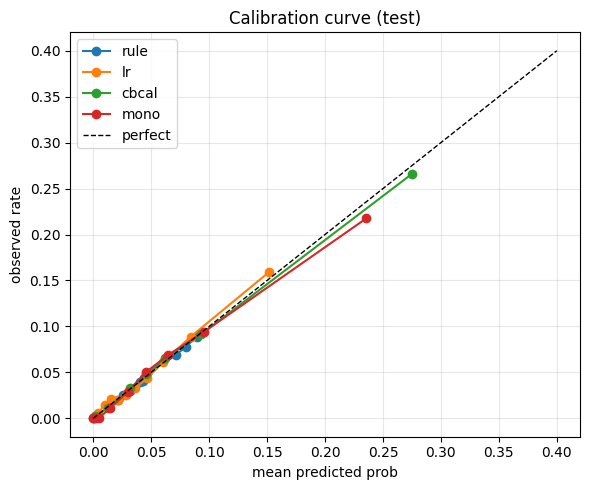

In [19]:
# ============================================================
# 5-2. Calibration curve (test)
# ============================================================
from sklearn.calibration import calibration_curve
plt.figure(figsize=(6, 5))
for nm, p in dict(rule=p_rule_te, lr=p_lr_te, cbcal=p_cb_te, mono=p_mono_te).items():
    fr, mp = calibration_curve(yte, p, n_bins=10, strategy="quantile")
    plt.plot(mp, fr, marker="o", label=nm)
plt.plot([0, 0.4], [0, 0.4], "k--", lw=1, label="perfect")
plt.xlabel("mean predicted prob"); plt.ylabel("observed rate")
plt.title("Calibration curve (test)"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(REPORT_DIR / "fig_calibration.png", dpi=120); plt.show()


할인율 반응 곡선(평균 구매확률):
       rule      lr   cbcal    mono
0%   0.0435  0.0394  0.1330  0.0465
5%   0.0331  0.0406  0.1101  0.0467
10%  0.0331  0.0418  0.0743  0.0467
15%  0.0460  0.0431  0.0477  0.0468
20%  0.0460  0.0445  0.0509  0.0468
25%  0.0429  0.0459  0.0520  0.0468
30%  0.0647  0.0474  0.0530  0.0469
35%  0.0647  0.0489  0.0541  0.0469
40%  0.0647  0.0505  0.0548  0.0470
단조성 만족: {'rule': False, 'lr': True, 'cbcal': False, 'mono': True}


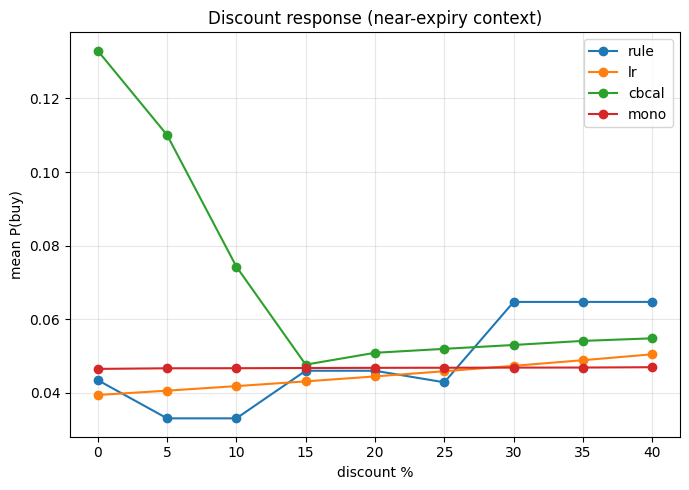


[원시] 할인구간별 y-rate (교란 포함):
disc_bin
d00    0.0469
d10    0.0062
d20    0.0440
d30    0.0353
d40    0.0728

[조건부] days_to_expiry==0 & 가격민감도 상위 1/3 에서 할인구간별 y-rate:
disc_bin
d00    0.0681
d10       NaN
d20    0.0435
d30       NaN
d40    0.0804


In [20]:
# ============================================================
# 5-3. 할인 반응곡선·단조성 진단 (+할인-임박 교란 실증)
# ============================================================
# 임박 재고(days_to_expiry<=1) 문맥 4,000행을 고정하고 할인율만 0~40% grid 로 바꿔
# 각 모델의 평균 구매확률을 본다. 시뮬레이터가 A-2/A-3에서 할 '반사실 질문' 그 자체다.
sample = te[te["days_to_expiry"] <= 1].sample(4000, random_state=SEED).reset_index(drop=True)
grid = np.arange(0, 0.45, 0.05)
resp = {}
for g in grid:
    s2 = sample.copy()
    s2["discount_ratio"] = g
    s2["discount_rate"] = int(g * 100)
    s2["ps_x_disc"] = s2["price_sensitivity"] * g
    s2["disc_x_near"] = g * s2["near_expiry"]
    resp.setdefault("rule", []).append(rule_model.predict_proba_pos(s2).mean())
    resp.setdefault("lr", []).append(lr_pipe.predict_proba(s2[ALL_FEATURES])[:, 1].mean())
    if HAS_CATBOOST:
        resp.setdefault("cbcal", []).append(
            iso.transform(cb.predict_proba(pd.concat([s2[CAT_FEATURES], s2[NUM_FEATURES]], axis=1))[:, 1]).mean())
    else:
        resp.setdefault("cbcal", []).append(iso.transform(cb.predict_proba(enc_X(s2))[:, 1]).mean())
    resp.setdefault("mono", []).append(mono.predict_proba(enc_X(s2))[:, 1].mean())
resp_df = pd.DataFrame(resp, index=[f"{int(g*100)}%" for g in grid])
print("할인율 반응 곡선(평균 구매확률):")
print(resp_df.round(4).to_string())
mono_ok = {m: bool(np.all(np.diff(resp_df[m].to_numpy()) >= -1e-6)) for m in resp_df.columns}
print("단조성 만족:", mono_ok)
resp_df.to_csv(REPORT_DIR / "b1_discount_response.csv")

plt.figure(figsize=(7, 5))
for m in resp_df.columns:
    plt.plot(grid * 100, resp_df[m], marker="o", label=m)
plt.xlabel("discount %"); plt.ylabel("mean P(buy)")
plt.title("Discount response (near-expiry context)")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(REPORT_DIR / "fig_discount_response.png", dpi=120); plt.show()

# --- 교란(confounding) 실증: 할인은 '임박 로트'에 규칙적으로 붙는다 ---
# 원시 상관으로 보면 할인이 클수록 구매율이 낮아 보이지만(임박 로트라서),
# 카테고리·유통기한을 '고정'하면 실제 조건부 탄력성은 완만한 양수다. (심슨의 역설)
obs = te.copy()
obs["disc_bin"] = pd.cut(obs["discount_ratio"], DISC_BINS, labels=DISC_LABELS)
print("\n[원시] 할인구간별 y-rate (교란 포함):")
print(obs.groupby("disc_bin")["y"].mean().round(4).to_string())
print("\n[조건부] days_to_expiry==0 & 가격민감도 상위 1/3 에서 할인구간별 y-rate:")
ps_hi = obs["price_sensitivity"] >= obs["price_sensitivity"].quantile(2/3)
print(obs[(obs["days_to_expiry"] == 0) & ps_hi].groupby("disc_bin")["y"].mean().round(4).to_string())


In [21]:
# ============================================================
# 5-4. 시뮬레이터 모델 선정·저장
# ============================================================
# 선정 기준: (1) 반사실 예측 안전성(할인 단조성) 필수 (2) 그 안에서 판별력·보정 최고.
#  - cbcal 은 AUC 최고지만 '할인=임박 로트' 교란을 그대로 학습해 0% 할인에서 확률이
#    튀는 비단조 반응 -> A-2/A-3 최적화에 사용하면 오답 유도 위험.
#  - 따라서 시뮬레이터 채택 = mono (단조 제약 GBM). lr 은 백업.
import joblib
SELECTED = "mono"
joblib.dump(dict(rule=rule_model, lr=lr_pipe, cb=cb, iso=iso, mono=mono, enc=enc,
                 CAT_FEATURES=CAT_FEATURES, NUM_FEATURES=NUM_FEATURES,
                 cb_backend=cb_backend, mono_backend=mono_backend, selected=SELECTED),
            MODEL_DIR / "b1_models.joblib")
print("saved ->", MODEL_DIR / "b1_models.joblib", "/ selected:", SELECTED, f"({mono_backend})")


saved -> /content/b1_outputs/models/b1_models.joblib / selected: mono (MonotonicLightGBM)


In [22]:
# ============================================================
# 6-1. 가상 소비자 군체: 페르소나·방문 표집 가중치·수량 분포
# ============================================================
# 에이전트 = customer.csv 의 10,000명 페르소나 + memory 상태(6-2) + 구매확률 모델(5-4).
cust_ids = customer_df["customer_id"].to_numpy()
cust_i = {c: i for i, c in enumerate(cust_ids)}
cats_all = sorted(product_df["category"].unique())
cat_i = {c: i for i, c in enumerate(cats_all)}
prod_ids = product_df["product_id"].to_numpy()
prod_i = {p: i for i, p in enumerate(prod_ids)}
nC, nK, nP = len(cust_ids), len(cats_all), len(prod_ids)

# 방문자 표집 가중치: 학습기간 방문횟수 + 0.1 (한 번도 안 온 고객도 소량 확률)
w = vis[vis["visit_date"] <= TRAIN_END].groupby("customer_id").size()
cust_w = np.full(nC, 0.1)
for cid, v in w.items():
    cust_w[cust_i[cid]] = v + 0.1
cust_p = cust_w / cust_w.sum()

# 구매 수량 분포: category x 할인여부별 경험분포 (1~5 clip)
rtr = rec[rec["sale_date"] <= TRAIN_END].copy()
rtr["disc_flag"] = (rtr["discount_rate"] > 0).astype(int)
qty_dist = {}
for (c, f), g in rtr.groupby(["category", "disc_flag"]):
    vc = g["quantity"].clip(1, 5).value_counts(normalize=True).sort_index()
    qty_dist[(c, f)] = (vc.index.to_numpy(), vc.to_numpy())
print("agents:", nC, "/ categories:", nK, "/ products:", nP,
      "/ qty_dist keys:", len(qty_dist))


agents: 10000 / categories: 5 / products: 38 / qty_dist keys: 10


In [23]:
# ============================================================
# 6-2. Memory 초기상태 스냅샷 (임의 시점 asof)
# ============================================================
# 시뮬레이션 시작일 직전까지의 구매 이력으로 memory 배열을 초기화한다.
#  - mc_s/mc_l: 고객 x 카테고리 (점수, 마지막 구매일)   - mp_s/mp_l: 고객 x 상품
#  - deal: 고객 할인 EWMA (-1 = 이력 없음)
def init_mem(ev, keys, shape, idx_maps, asof):
    score = np.zeros(shape); last = np.full(shape, -10**6, dtype=np.int64)
    e = ev[ev["sale_date"] < asof].sort_values("sale_date").groupby(keys, as_index=False).last()
    di = e["sale_date"].values.astype("datetime64[D]").astype(np.int64)
    for r in range(len(e)):
        ii = tuple(m[e[k].iloc[r]] for m, k in zip(idx_maps, keys))
        score[ii] = e["mem_score_at_event"].iloc[r]
        last[ii] = di[r]
    return score, last

def init_all_mem(asof):
    a, b = init_mem(ev_cat, ["customer_id", "category"], (nC, nK), [cust_i, cat_i], asof)
    c, d = init_mem(ev_prod, ["customer_id", "product_id"], (nC, nP), [cust_i, prod_i], asof)
    e = ev_cust[ev_cust["sale_date"] < asof].groupby("customer_id").last()
    de = np.full(nC, -1.0)
    for cid, v in e["deal_ewma_at_event"].items():
        de[cust_i[cid]] = v
    return a, b, c, d, de
print("init_all_mem 준비 완료")


init_all_mem 준비 완료


In [24]:
# ============================================================
# 6-3. 오퍼 문맥 테이블·구매확률 predict 함수
# ============================================================
ctx = (offer_df.assign(is_fresh_alt=((offer_df["discount_rate"] == 0) & (offer_df["days_to_expiry"] > 2)).astype(int))
       .groupby(["store_id", "product_id", "date"], as_index=False)
       .agg(variant_count=("offer_id", "count"), fresh_alt_available=("is_fresh_alt", "max")))
offer_all = offer_df.merge(ctx, on=["store_id", "product_id", "date"], how="left")

cust_feat = customer_df.set_index("customer_id")
store_feat = store_df.set_index("store_id")[["area_type", "floating_idx"]]
cal_feat = calendar_df.set_index("date")

def predict_prob(feat_df):
    """B-1 표준 predict: enc(범주 12) + 수치 23 -> 선정 모델(mono) 구매확률."""
    X = np.hstack([enc.transform(feat_df[CAT_FEATURES]),
                   feat_df[NUM_FEATURES].to_numpy(float)])
    return mono.predict_proba(X)[:, 1]
print("offer_all:", offer_all.shape)


offer_all: (53249, 17)


In [25]:
# ============================================================
# 7-1. 몬테카를로 시뮬레이션 프로토콜 (run_sim)
# ============================================================
# 하루/점포/슬롯 루프:
#  (1) 방문계획: 실제 store x date x slot 방문자 '수'를 그대로 사용 (수요 규모는 A-1 담당,
#      B-1은 '방문자가 주어졌을 때의 선택'을 담당 - 역할 분리)
#  (2) 고객 표집: 방문횟수 가중 비복원 추출
#  (3) 고려집합: CONSIDER_SIZE=4, PREF_BOOST=0.5 (학습 표집과 동일 프로토콜!)
#  (4) 피처 조립(메모리 배열 asof 조회) -> mono 확률 -> (보정) -> 베르누이
#  (5) 구매 확정 순서를 랜덤 셔플해 재고 차감 (품절 반영)
#  (6) memory stream 갱신: s <- s*DECAY^gap + 1, deal EWMA <- 0.8*old + 0.2*할인율
CONSIDER_SIZE = 4
N_MC = 20
CAL_START, CAL_END = pd.Timestamp("2025-10-15"), pd.Timestamp("2025-10-28")   # 보정용(검증기간 내)
SIM_START, SIM_END = pd.Timestamp("2025-12-01"), pd.Timestamp("2025-12-14")   # 기준결과(테스트기간 내)

def run_sim(start, end, n_runs, slot_factor=None, cat_factor=None, seed0=1000):
    vwin = vis[(vis["visit_date"] >= start) & (vis["visit_date"] <= end)]
    visit_plan = (vwin.groupby(["store_id", "visit_date", "time_slot"], as_index=False)
                      .size().rename(columns={"size": "n_visits"}))
    m0 = init_all_mem(start)
    results = []
    for run in range(n_runs):
        rng = np.random.default_rng(SEED + seed0 + run)
        mc_s, mc_l, mp_s, mp_l, deal = [x.copy() for x in m0]
        logs = []
        for d in pd.date_range(start, end):
            d_int = np.int64(d.to_datetime64().astype("datetime64[D]").astype(np.int64))
            cal = cal_feat.loc[d]
            for sid, g_plan in visit_plan[visit_plan["visit_date"] == d].groupby("store_id"):
                offers = offer_all[(offer_all["store_id"] == sid) & (offer_all["date"] == d)].reset_index(drop=True)
                if len(offers) == 0:
                    continue
                avail = offers["available_qty"].to_numpy(float).copy()
                o_cat = offers["category"].to_numpy()
                cat_idx_map = {c: np.where(o_cat == c)[0] for c in np.unique(o_cat)}
                n_off = len(offers)
                for slot, n_v in g_plan.set_index("time_slot")["n_visits"].items():
                    if n_v == 0:
                        continue
                    shoppers = rng.choice(nC, size=min(int(n_v), nC), replace=False, p=cust_p)
                    # [피드백 반영] 재고 가중 노출 + 고객별 비복원 추출
                    _av0 = offers["available_qty"].to_numpy(float).clip(0.0) + 1e-9
                    p_exp = _av0 / _av0.sum()
                    kk = min(CONSIDER_SIZE, n_off)
                    idx = np.stack([rng.choice(n_off, size=kk, replace=False, p=p_exp) for _ in range(len(shoppers))])
                    use_pref = rng.random((len(shoppers), kk)) < PREF_BOOST
                    pref = cust_feat["preferred_category"].to_numpy()[shoppers]
                    for j in range(len(shoppers)):
                        ci = cat_idx_map.get(pref[j])
                        if ci is None:
                            continue
                        tk = use_pref[j]
                        if tk.any():
                            pc = p_exp[ci] / p_exp[ci].sum()
                            picks = rng.choice(ci, size=min(tk.sum(), len(ci)), replace=False, p=pc)
                            slots = np.where(tk)[0][:len(picks)]
                            for s_, pk in zip(slots, picks):
                                if pk not in idx[j]:
                                    idx[j, s_] = pk
                    sh_rep = np.repeat(shoppers, CONSIDER_SIZE)
                    of_rep = idx.ravel()
                    F = offers.iloc[of_rep][["product_id", "category", "base_price", "shelf_life_days",
                                             "freshness_decay_type", "discount_rate", "discount_ratio",
                                             "days_to_expiry", "freshness_score", "unit_price",
                                             "discount_price", "variant_count", "fresh_alt_available"]].reset_index(drop=True)
                    C = cust_feat.iloc[sh_rep].reset_index()
                    F = pd.concat([F, C], axis=1)
                    F["time_slot"] = slot
                    F["day_type_cal"] = cal["day_type"]; F["season"] = cal["season"]
                    F["day_of_week"] = cal["day_of_week"]; F["is_weekend"] = cal["is_weekend"]
                    F["is_holiday"] = cal["is_holiday"]; F["month"] = cal["month"]
                    F["area_type"] = store_feat.loc[sid, "area_type"]
                    F["floating_idx"] = store_feat.loc[sid, "floating_idx"]
                    ci_arr = np.array([cat_i[c] for c in F["category"]])
                    pi_arr = np.array([prod_i[p] for p in F["product_id"]])
                    gap_c = d_int - mc_l[sh_rep, ci_arr]
                    gap_p = d_int - mp_l[sh_rep, pi_arr]
                    F["mem_cat_score"] = mc_s[sh_rep, ci_arr] * (MEM_DECAY ** np.clip(gap_c, 0, 500))
                    F["mem_cat_days_since"] = np.clip(gap_c, 0, 999)
                    F["mem_prod_score"] = mp_s[sh_rep, pi_arr] * (MEM_DECAY ** np.clip(gap_p, 0, 500))
                    F["mem_prod_days_since"] = np.clip(gap_p, 0, 999)
                    F["mem_cust_deal_ewma"] = deal[sh_rep]
                    F["is_pref_category"] = (F["category"] == F["preferred_category"]).astype(int)
                    F["expiry_ratio"] = (F["days_to_expiry"] / F["shelf_life_days"]).clip(0, 1)
                    F["log_base_price"] = np.log1p(F["base_price"])
                    F["ps_x_disc"] = F["price_sensitivity"] * F["discount_ratio"]
                    F["fs_x_fresh"] = F["freshness_sensitivity"] * F["freshness_score"]
                    F["near_expiry"] = (F["days_to_expiry"] <= 1).astype(int)
                    F["disc_x_near"] = F["discount_ratio"] * F["near_expiry"]
                    for c in CAT_FEATURES:
                        F[c] = F[c].astype(str)
                    p = predict_prob(F)
                    if slot_factor is not None:
                        f = slot_factor.get(slot, 1.0) * np.array([cat_factor.get(c, 1.0) for c in F["category"]])
                        p = np.clip(f * p / (f * p + (1 - p)), 0, 0.98)   # odds scaling
                    buy = rng.random(len(p)) < p
                    if not buy.any():
                        continue
                    for k in rng.permutation(np.where(buy)[0]):
                        oid = of_rep[k]
                        if avail[oid] <= 0:
                            continue
                        c_ = F.at[k, "category"]; f_ = int(F.at[k, "discount_rate"] > 0)
                        vals, probs = qty_dist.get((c_, f_), (np.array([1]), np.array([1.0])))
                        q = int(min(int(rng.choice(vals, p=probs)), avail[oid]))
                        if q <= 0:
                            continue
                        avail[oid] -= q
                        price = F.at[k, "discount_price"] if f_ else F.at[k, "unit_price"]
                        sh = sh_rep[k]
                        logs.append((sid, d, slot, F.at[k, "product_id"], c_,
                                     int(F.at[k, "discount_rate"]), q, float(price) * q,
                                     float(F.at[k, "unit_price"]) * q))
                        ci_, pi_ = cat_i[c_], prod_i[F.at[k, "product_id"]]
                        gc_ = d_int - mc_l[sh, ci_]
                        mc_s[sh, ci_] = mc_s[sh, ci_] * (MEM_DECAY ** max(gc_, 0)) + 1.0
                        mc_l[sh, ci_] = d_int
                        gp_ = d_int - mp_l[sh, pi_]
                        mp_s[sh, pi_] = mp_s[sh, pi_] * (MEM_DECAY ** max(gp_, 0)) + 1.0
                        mp_l[sh, pi_] = d_int
                        dr_ = float(F.at[k, "discount_rate"])
                        deal[sh] = dr_ if deal[sh] < 0 else 0.8 * deal[sh] + 0.2 * dr_
        L = pd.DataFrame(logs, columns=["store_id", "date", "time_slot", "product_id", "category",
                                        "discount_rate", "qty", "revenue", "gross"])
        L["run"] = run
        results.append(L)
    return pd.concat(results, ignore_index=True)
print("run_sim 정의 완료")


run_sim 정의 완료


In [26]:
# ============================================================
# 7-2. 강도 보정 계수 산출 (검증기간, IPF)
# ============================================================
# 무보정 시뮬은 수량을 과소재현한다(고려집합 표집의 구조적 편향: 학습 positive 는
# '수요가 실제 실현된' 오퍼로 쏠리는데, 시뮬 고려집합은 순수 표집이라 노출 강도가 다름).
# 검증기간(10/15~10/28)의 실제 vs 시뮬 (slot x category) 판매수량 마진에
# IPF(iterative proportional fitting) 3회로 slot_factor / cat_factor 를 맞추고,
# 확률에는 odds scaling p' = f*p / (f*p + (1-p)) 으로 적용한다.
# * 보정 계수는 테스트기간이 아닌 '검증기간'에서만 산출 -> 평가 누수 없음.
t0 = time.time()
cal_sim = run_sim(CAL_START, CAL_END, n_runs=3, seed0=500)
cal_act = rec[(rec["sale_date"] >= CAL_START) & (rec["sale_date"] <= CAL_END)]
a_sc = cal_act.groupby(["time_slot", "category"])["quantity"].sum()
s_sc = (cal_sim.groupby(["run", "time_slot", "category"])["qty"].sum()
        .groupby(["time_slot", "category"]).mean())
M_a = a_sc.unstack(fill_value=0.0)
M_s = s_sc.unstack(fill_value=0.0).reindex(index=M_a.index, columns=M_a.columns).fillna(1e-9)
slot_f = pd.Series(1.0, index=M_a.index); cat_f = pd.Series(1.0, index=M_a.columns)
for _ in range(3):
    slot_f = slot_f * (M_a.sum(1) / (M_s.mul(cat_f, axis=1).mul(slot_f, axis=0)).sum(1))
    cat_f = cat_f * (M_a.sum(0) / (M_s.mul(cat_f, axis=1).mul(slot_f, axis=0)).sum(0))
slot_factor = slot_f.clip(0.3, 5.0).to_dict()
cat_factor = cat_f.clip(0.3, 5.0).to_dict()
print("보정계수 slot:", {k: round(v, 2) for k, v in slot_factor.items()})
print("보정계수 category:", {k: round(v, 2) for k, v in cat_factor.items()})
print("calibration time:", round(time.time() - t0, 1), "s")

import joblib
joblib.dump(dict(slot_factor=slot_factor, cat_factor=cat_factor,
                 CONSIDER_SIZE=CONSIDER_SIZE, PREF_BOOST=PREF_BOOST, MEM_DECAY=MEM_DECAY),
            MODEL_DIR / "b1_sim_calibration.joblib")


보정계수 slot: {'afternoon': 1.36, 'closing': 1.5, 'evening': 1.78, 'lunch': 2.22, 'morning': 2.65}
보정계수 category: {'cheese': 0.6, 'dairy': 0.8, 'deli': 0.97, 'meat': 1.14, 'produce': 1.1}
calibration time: 15.0 s


['/content/b1_outputs/models/b1_sim_calibration.joblib']

In [27]:
# ============================================================
# 7-3. 기준결과 몬테카를로 N=20회 실행 (테스트기간, 보정 적용)
# ============================================================
t0 = time.time()
sim_all = run_sim(SIM_START, SIM_END, n_runs=N_MC,
                  slot_factor=slot_factor, cat_factor=cat_factor, seed0=1000)
save_df(sim_all, "b1_sim_runs")
print("MC", N_MC, "runs:", round(time.time() - t0, 1), "s / rows:", len(sim_all))


MC 20 runs: 92.7 s / rows: 67698


=== 기간 합계 (2025-12-01 ~ 2025-12-14) ===
실제:      qty=6,436  rev=55,329,770
시뮬 평균: qty=4,512 (±45)  rev=37,694,356 (±867,235)
수량 비율: 0.701   매출 비율: 0.681

--- time_slot별 판매수량 ---
           actual  sim_mean  ratio
time_slot                         
afternoon    1357   1224.45   0.90
closing       856    688.85   0.80
evening      1812   1361.70   0.75
lunch        1443    814.90   0.56
morning       968    421.65   0.44

--- category별 판매수량 ---
          actual  sim_mean  ratio
category                         
cheese       290    296.05   1.02
dairy        910    719.95   0.79
deli         866    578.85   0.67
meat        1239    848.60   0.68
produce     3131   2068.10   0.66

일별 판매수량 상관계수: 0.896
실제 할인판매 수량 비중: 0.295
시뮬 할인판매 수량 비중: 0.477


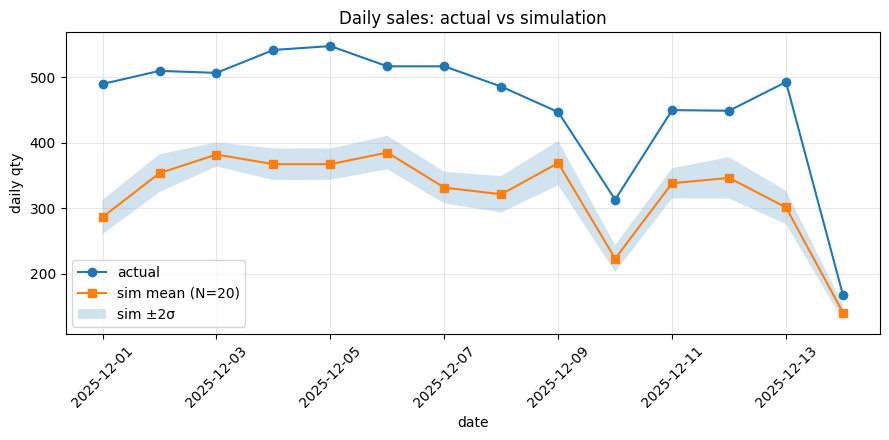

In [28]:
# ============================================================
# 7-4. 현실 정합성 검증 (+시각화)
# ============================================================
act = rec[(rec["sale_date"] >= SIM_START) & (rec["sale_date"] <= SIM_END)].copy()
act["revenue"] = act["line_amount"]
summ = sim_all.groupby("run").agg(qty=("qty", "sum"), rev=("revenue", "sum"))
print(f"=== 기간 합계 ({SIM_START.date()} ~ {SIM_END.date()}) ===")
print(f"실제:      qty={act['quantity'].sum():,}  rev={act['revenue'].sum():,.0f}")
print(f"시뮬 평균: qty={summ['qty'].mean():,.0f} (±{summ['qty'].std():.0f})  rev={summ['rev'].mean():,.0f} (±{summ['rev'].std():,.0f})")
print(f"수량 비율: {summ['qty'].mean()/act['quantity'].sum():.3f}   매출 비율: {summ['rev'].mean()/act['revenue'].sum():.3f}")
for dim in ["time_slot", "category"]:
    a = act.groupby(dim)["quantity"].sum()
    s = sim_all.groupby(["run", dim])["qty"].sum().groupby(dim).mean()
    cmpd = pd.DataFrame({"actual": a, "sim_mean": s})
    cmpd["ratio"] = cmpd["sim_mean"] / cmpd["actual"]
    print(f"\n--- {dim}별 판매수량 ---")
    print(cmpd.round(2).to_string())
a_d = act.groupby("sale_date")["quantity"].sum()
s_d = sim_all.groupby(["run", "date"])["qty"].sum().groupby("date").mean()
s_sd = sim_all.groupby(["run", "date"])["qty"].sum().groupby("date").std()
corr = np.corrcoef(a_d.to_numpy(), s_d.reindex(a_d.index).to_numpy())[0, 1]
print("\n일별 판매수량 상관계수:", round(corr, 3))
print("실제 할인판매 수량 비중:", round(act.loc[act['discount_rate'] > 0, 'quantity'].sum() / act['quantity'].sum(), 3))
print("시뮬 할인판매 수량 비중:", round(sim_all.loc[sim_all['discount_rate'] > 0, 'qty'].sum() / sim_all['qty'].sum(), 3))

plt.figure(figsize=(9, 4.5))
plt.plot(a_d.index, a_d.values, marker="o", label="actual")
plt.plot(s_d.index, s_d.values, marker="s", label=f"sim mean (N={N_MC})")
plt.fill_between(s_d.index, (s_d - 2*s_sd).values, (s_d + 2*s_sd).values, alpha=0.2, label="sim ±2σ")
plt.xlabel("date"); plt.ylabel("daily qty"); plt.title("Daily sales: actual vs simulation")
plt.legend(); plt.grid(alpha=0.3); plt.xticks(rotation=45)
plt.tight_layout(); plt.savefig(REPORT_DIR / "fig_daily_sim_vs_actual.png", dpi=120); plt.show()


In [29]:
# ============================================================
# 8. A-1 / B-2 인터페이스 산출물 저장
# ============================================================
# 8-1. 기준결과 테이블: store x date x time_slot x product, MC 평균/표준편차
#      = "기존 마감할인 정책을 그대로 둘 때"의 기대 판매·매출·할인액 (A-2 비교 기준선)
g = (sim_all.groupby(["run", "store_id", "date", "time_slot", "product_id", "category"], as_index=False)
            .agg(qty=("qty", "sum"), revenue=("revenue", "sum"), gross=("gross", "sum")))
cells = g[["store_id", "date", "time_slot", "product_id", "category"]].drop_duplicates()
full = cells.merge(pd.DataFrame({"run": range(N_MC)}), how="cross")
g = full.merge(g, on=["run", "store_id", "date", "time_slot", "product_id", "category"], how="left").fillna(0)
base = (g.groupby(["store_id", "date", "time_slot", "product_id", "category"], as_index=False)
          .agg(qty_mean=("qty", "mean"), qty_std=("qty", "std"),
               revenue_mean=("revenue", "mean"), revenue_std=("revenue", "std"),
               gross_mean=("gross", "mean")))
base["discount_amount_mean"] = base["gross_mean"] - base["revenue_mean"]
num_cols = base.select_dtypes("number").columns
base[num_cols] = base[num_cols].round(3)
base.to_csv(IFACE_DIR / "b1_baseline_result.csv", index=False, encoding="utf-8-sig")
print("8-1 b1_baseline_result.csv:", base.shape)

# 8-2. 기존 마감할인 정책 테이블 (시뮬 기간의 오퍼 상태 그대로)
pol = offer_df[offer_df["date"] >= SIM_START][
    ["store_id", "product_id", "category", "date", "discount_rate",
     "days_to_expiry", "freshness_score", "available_qty", "unit_price", "discount_price"]
].sort_values(["store_id", "date", "product_id", "discount_rate"])
pol.to_csv(IFACE_DIR / "b1_policy_table.csv", index=False, encoding="utf-8-sig")
print("8-2 b1_policy_table.csv:", pol.shape)

# 8-3. 가상 소비자 군체(agent pool): 페르소나 + memory 초기상태 (B-2가 그대로 이어받아 시뮬)
mc_s0, mc_l0, mp_s0, mp_l0, deal0 = init_all_mem(SIM_START)
joblib.dump(dict(asof=str(SIM_START.date()), mem_decay=MEM_DECAY,
                 customer_ids=cust_ids, categories=cats_all, product_ids=prod_ids,
                 mem_cat_score=mc_s0, mem_cat_last_day=mc_l0,
                 mem_prod_score=mp_s0, mem_prod_last_day=mp_l0,
                 deal_ewma=deal0, persona=customer_df),
            IFACE_DIR / "b1_agent_pool.joblib", compress=3)
print("8-3 b1_agent_pool.joblib: 고객", nC, "명 / memory 보유 비율",
      round(float((mc_l0 > 0).mean()), 3))

# 8-4. predict 입력 스키마·프로토콜 상수 (B-2/A-2와의 계약서)
spec = dict(
    model_file="b1_models.joblib", selected_model=f"mono ({mono_backend})",
    predict="p = mono.predict_proba(hstack([enc.transform(X[CAT_FEATURES]), X[NUM_FEATURES]]))[:,1]",
    CAT_FEATURES=CAT_FEATURES, NUM_FEATURES=NUM_FEATURES,
    protocol=dict(CONSIDER_SIZE=CONSIDER_SIZE, PREF_BOOST=PREF_BOOST, MEM_DECAY=MEM_DECAY,
                  qty_clip=[1, 5], calibration="b1_sim_calibration.joblib (slot/category odds scaling)"),
    discount_rate_unit="receipt/inventory: 0~40 정수 %, product.max_discount_rate: 0~0.4 비율",
    time_grid="B-1: time_slot(morning/lunch/afternoon/evening/closing) - A-1의 hour 격자와 매핑 필요(store_visitor_profile 참조)",
)
with open(IFACE_DIR / "b1_predict_spec.json", "w", encoding="utf-8") as f:
    json.dump(spec, f, ensure_ascii=False, indent=2)
print("8-4 b1_predict_spec.json 저장")
print("\n최종 산출물:")
for p in sorted(IFACE_DIR.iterdir()) + sorted(MODEL_DIR.iterdir()) + sorted(REPORT_DIR.iterdir()):
    print(" -", p.relative_to(OUTPUT_DIR), f"({p.stat().st_size/1024:.0f} KB)")


8-1 b1_baseline_result.csv: (5999, 11)
8-2 b1_policy_table.csv: (4502, 10)
8-3 b1_agent_pool.joblib: 고객 10000 명 / memory 보유 비율 0.681
8-4 b1_predict_spec.json 저장

최종 산출물:
 - interface/b1_agent_pool.joblib (919 KB)
 - interface/b1_baseline_result.csv (424 KB)
 - interface/b1_policy_table.csv (223 KB)
 - interface/b1_predict_spec.json (1 KB)
 - models/b1_models.joblib (3821 KB)
 - models/b1_sim_calibration.joblib (0 KB)
 - reports/b1_discount_response.csv (1 KB)
 - reports/b1_model_comparison.csv (1 KB)
 - reports/fig_calibration.png (55 KB)
 - reports/fig_daily_sim_vs_actual.png (72 KB)
 - reports/fig_discount_response.png (51 KB)


In [30]:
# 실행 결과 요약 저장 + 전체 산출물 zip 다운로드
import io, shutil
from contextlib import redirect_stdout
from google.colab import files

buf = io.StringIO()
with redirect_stdout(buf):
    print("[백엔드]")
    print("catboost:", HAS_CATBOOST, "/ lightgbm:", HAS_LGBM)
    print("cb_backend:", cb_backend, "/ mono_backend:", mono_backend)
    print("\n[5-1 모델 비교]")
    print(cmp_df.round(4).to_string(index=False))
    print("\n[5-3 할인 반응곡선]")
    print(resp_df.round(4).to_string())
    print("단조성 만족:", mono_ok)
    print("\n[7-2 보정계수]")
    print("slot:", {k: round(v, 3) for k, v in slot_factor.items()})
    print("category:", {k: round(v, 3) for k, v in cat_factor.items()})
    print("\n[7-4 검증]")
    print(f"기간: {SIM_START.date()} ~ {SIM_END.date()} / N_MC={N_MC}")
    print(f"실제      qty={act['quantity'].sum():,}  rev={act['revenue'].sum():,.0f}")
    print(f"시뮬 평균 qty={summ['qty'].mean():,.1f} (±{summ['qty'].std():.1f})  rev={summ['rev'].mean():,.0f} (±{summ['rev'].std():,.0f})")
    print(f"수량 비율 {summ['qty'].mean()/act['quantity'].sum():.3f} / 매출 비율 {summ['rev'].mean()/act['revenue'].sum():.3f}")
    for dim in ["time_slot", "category"]:
        a = act.groupby(dim)["quantity"].sum()
        s = sim_all.groupby(["run", dim])["qty"].sum().groupby(dim).mean()
        c = pd.DataFrame({"actual": a, "sim_mean": s}); c["ratio"] = c["sim_mean"] / c["actual"]
        print(f"\n--- {dim} ---"); print(c.round(3).to_string())
    a_d = act.groupby("sale_date")["quantity"].sum()
    s_d = sim_all.groupby(["run", "date"])["qty"].sum().groupby("date").mean()
    print("\n일별 상관:", round(np.corrcoef(a_d.to_numpy(), s_d.reindex(a_d.index).to_numpy())[0, 1], 4))
    print("실제 할인판매 비중:", round(act.loc[act['discount_rate'] > 0, 'quantity'].sum() / act['quantity'].sum(), 4))
    print("시뮬 할인판매 비중:", round(sim_all.loc[sim_all['discount_rate'] > 0, 'qty'].sum() / sim_all['qty'].sum(), 4))
    print("\n[일별 실제 vs 시뮬]")
    print(pd.DataFrame({"actual": a_d, "sim_mean": s_d.reindex(a_d.index).round(1)}).to_string())

txt = buf.getvalue()
print(txt)
open("/content/b1_outputs/reports/b1_run_summary.txt", "w", encoding="utf-8").write(txt)
shutil.make_archive("/content/b1_결과", "zip", "/content/b1_outputs")
files.download("/content/b1_결과.zip")

[백엔드]
catboost: True / lightgbm: True
cb_backend: CatBoost / mono_backend: MonotonicLightGBM

[5-1 모델 비교]
split model    AUC  LogLoss  Brier    ECE
valid  rule 0.6343   0.1850 0.0445 0.0008
valid    lr 0.7512   0.1702 0.0426 0.0023
valid cbcal 0.8777   0.1257 0.0329 0.0000
valid  mono 0.8621   0.1399 0.0374 0.0033
 test  rule 0.6330   0.1850 0.0445 0.0012
 test    lr 0.7472   0.1711 0.0428 0.0016
 test cbcal 0.8732   0.1408 0.0342 0.0018
 test  mono 0.8569   0.1437 0.0385 0.0026

[5-3 할인 반응곡선]
       rule      lr   cbcal    mono
0%   0.0435  0.0394  0.1330  0.0465
5%   0.0331  0.0406  0.1101  0.0467
10%  0.0331  0.0418  0.0743  0.0467
15%  0.0460  0.0431  0.0477  0.0468
20%  0.0460  0.0445  0.0509  0.0468
25%  0.0429  0.0459  0.0520  0.0468
30%  0.0647  0.0474  0.0530  0.0469
35%  0.0647  0.0489  0.0541  0.0469
40%  0.0647  0.0505  0.0548  0.0470
단조성 만족: {'rule': False, 'lr': True, 'cbcal': False, 'mono': True}

[7-2 보정계수]
slot: {'afternoon': 1.357, 'closing': 1.496, 'evening': 1.782, 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>